In [1]:
from pathlib import Path

PROJECT_ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / "data").is_dir() and (path / "notebooks").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from inside the project directory.")

DATABASE_PATH = PROJECT_ROOT / "database" / "hdb.duckdb"
DATABASE_PATH.parent.mkdir(parents=True, exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "hdb_resale_clean.csv")

df["month"] = pd.to_datetime(df["month"])

df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,...,quarter,price_per_sqm,flat_age,storey_lower,storey_upper,storey_midpoint,remaining_lease_years,remaining_lease_extra_months,remaining_lease_months,remaining_lease_years_numeric
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,...,2017Q1,5272.73,38,10,12,11.0,61,4,736,61.33
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,...,2017Q1,3731.34,39,1,3,2.0,60,7,727,60.58
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,...,2017Q1,3910.45,37,1,3,2.0,62,5,749,62.42
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,...,2017Q1,3897.06,37,4,6,5.0,62,1,745,62.08
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,...,2017Q1,3955.22,37,1,3,2.0,62,5,749,62.42


In [2]:
df.shape

(239330, 22)

In [22]:
import duckdb

con = duckdb.connect(str(DATABASE_PATH))

In [23]:
growth_analysis = con.execute("""
    WITH annual_town_stats AS (
        SELECT
            town,
            year,
            COUNT(*) AS transactions,
            MEDIAN(price_per_sqm) AS median_price_per_sqm
        FROM resale_transactions
        GROUP BY town, year
    ),

    with_previous_year AS (
        SELECT
            town,
            year,
            transactions,
            median_price_per_sqm,

            LAG(transactions) OVER (
                PARTITION BY town
                ORDER BY year
            ) AS previous_year_transactions,

            LAG(median_price_per_sqm) OVER (
                PARTITION BY town
                ORDER BY year
            ) AS previous_year_price_per_sqm

        FROM annual_town_stats
    )

    SELECT
        town,
        year,
        transactions,

        ROUND(
            median_price_per_sqm,
            2
        ) AS median_price_per_sqm,

        ROUND(
            100.0 * (transactions - previous_year_transactions)
            / previous_year_transactions,
            2
        ) AS transaction_growth_pct,

        ROUND(
            100.0 * (median_price_per_sqm - previous_year_price_per_sqm)
            / previous_year_price_per_sqm,
            2
        ) AS price_growth_pct

    FROM with_previous_year
    ORDER BY town, year
""").fetchdf()

In [24]:
growth_analysis.head()

,town,year,transactions,median_price_per_sqm,transaction_growth_pct,price_growth_pct
0,ANG MO KIO,2017,942,4632.35,NaN,NaN
1,ANG MO KIO,2018,1014,4368.70,7.64,-5.69
2,ANG MO KIO,2019,954,4117.65,-5.92,-5.75
3,ANG MO KIO,2020,997,4239.13,4.51,2.95
4,ANG MO KIO,2021,1055,4756.10,5.82,12.20


## Question 1 — How has the HDB resale market changed?

In [3]:
annual_transactions = (
    df[df["year"] <= 2025]
    .groupby("year")
    .size()
    .reset_index(name="transactions")
)

annual_transactions

,year,transactions
0,2017,20509
1,2018,21561
2,2019,22186
3,2020,23333
4,2021,29087
5,2022,26720
6,2023,25754
7,2024,27832
8,2025,25085


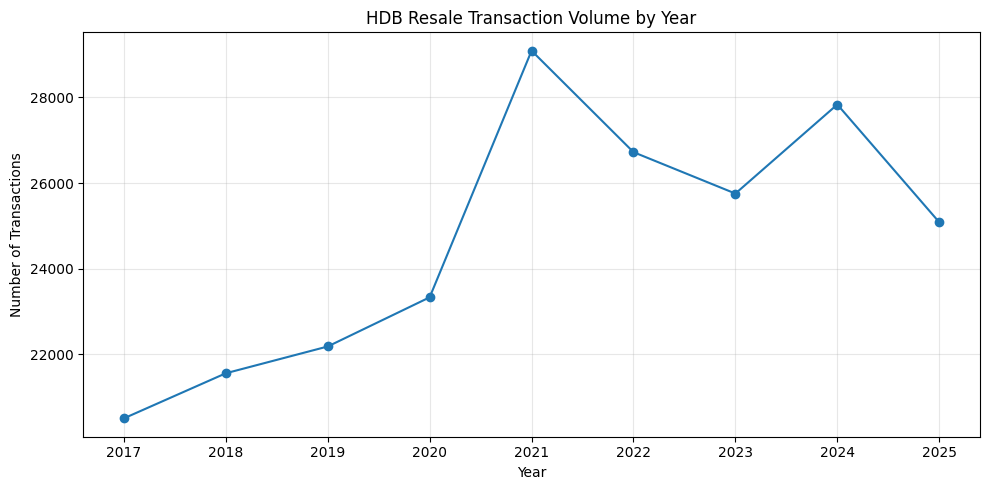

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(
    annual_transactions["year"],
    annual_transactions["transactions"],
    marker="o"
)

plt.title("HDB Resale Transaction Volume by Year")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
monthly_transactions = (
    df.groupby("month")
    .size()
    .reset_index(name="transactions")
)

monthly_transactions.head()

,month,transactions
0,2017-01-01,1185
1,2017-02-01,1085
2,2017-03-01,1903
3,2017-04-01,1839
4,2017-05-01,1980


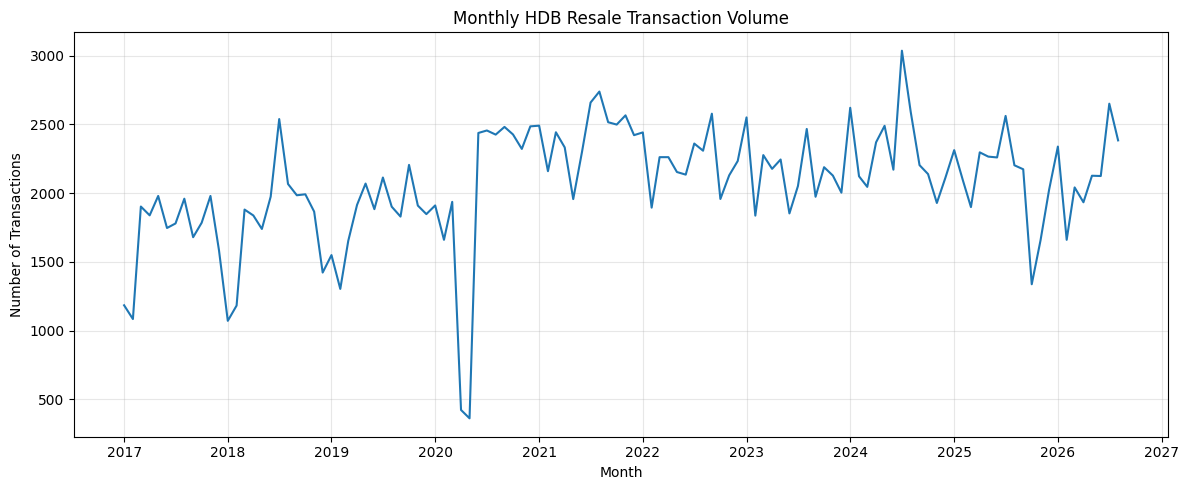

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_transactions["month"],
    monthly_transactions["transactions"]
)

plt.title("Monthly HDB Resale Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
annual_median_price = (
    df[df["year"] <= 2025]
    .groupby("year")["resale_price"]
    .median()
    .reset_index()
)

annual_median_price

,year,resale_price
0,2017,410000.0
1,2018,408000.0
2,2019,400000.0
3,2020,425000.0
4,2021,483000.0
5,2022,525000.0
6,2023,550000.0
7,2024,590000.0
8,2025,628000.0


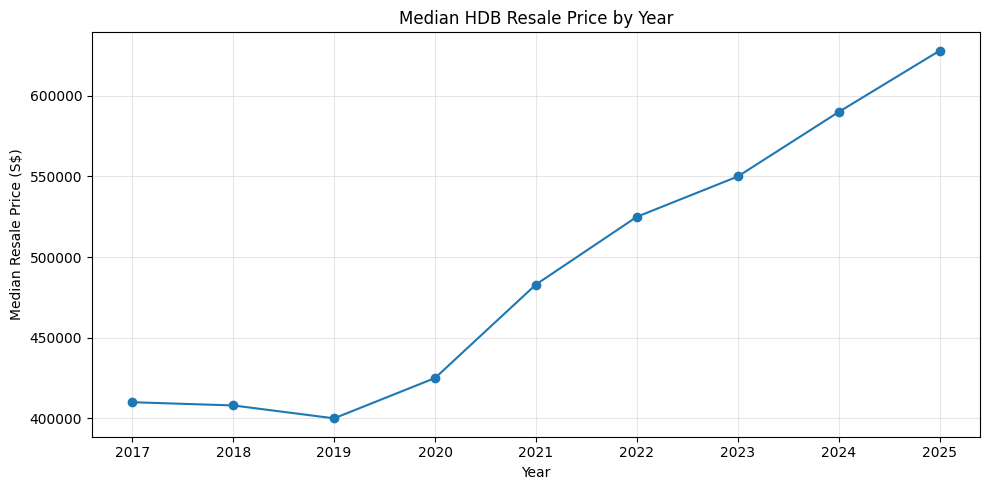

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    annual_median_price["year"],
    annual_median_price["resale_price"],
    marker="o"
)

plt.title("Median HDB Resale Price by Year")
plt.xlabel("Year")
plt.ylabel("Median Resale Price (S$)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
annual_psm = (
    df[df["year"] <= 2025]
    .groupby("year")["price_per_sqm"]
    .median()
    .reset_index()
)

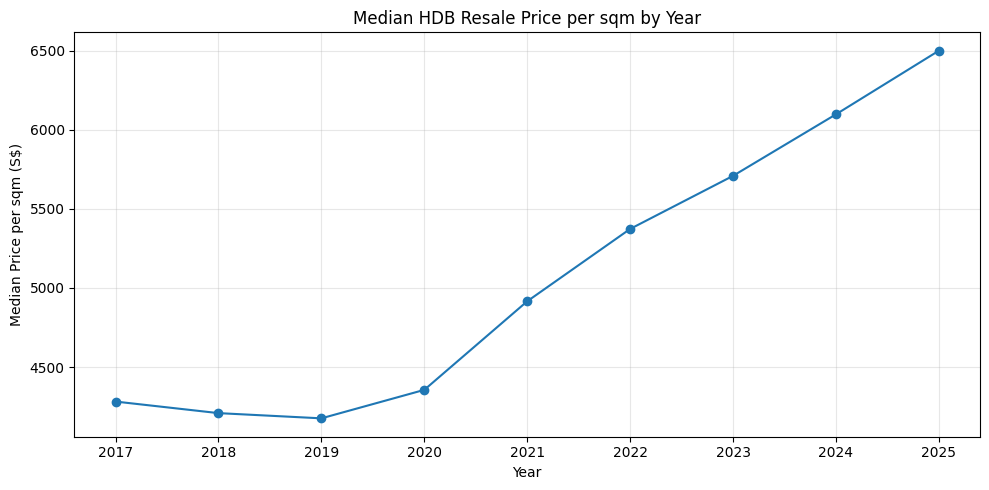

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    annual_psm["year"],
    annual_psm["price_per_sqm"],
    marker="o"
)

plt.title("Median HDB Resale Price per sqm by Year")
plt.xlabel("Year")
plt.ylabel("Median Price per sqm (S$)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Question 2 — Which towns are the largest markets?

In [11]:
town_transactions = (
    df.groupby("town")
    .size()
    .reset_index(name="transactions")
    .sort_values("transactions", ascending=False)
)

town_transactions.head(10)

,town,transactions
20,SENGKANG,19368
17,PUNGGOL,17331
24,WOODLANDS,17049
22,TAMPINES,16579
25,YISHUN,16248
13,JURONG WEST,15686
1,BEDOK,12459
11,HOUGANG,12086
8,CHOA CHU KANG,10744
3,BUKIT BATOK,10232


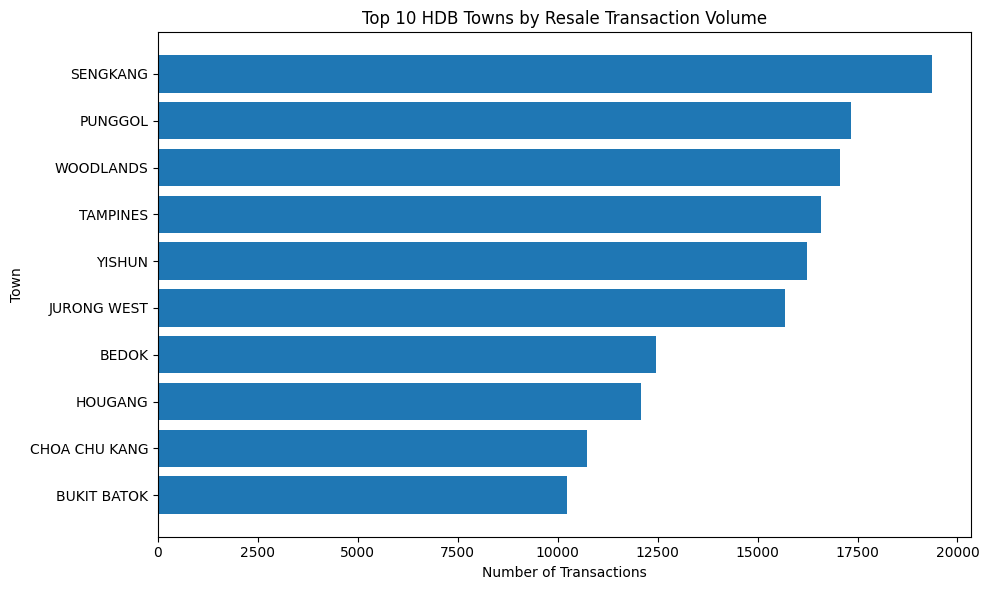

In [12]:
top10_transactions = town_transactions.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_transactions["town"],
    top10_transactions["transactions"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 HDB Towns by Resale Transaction Volume")
plt.xlabel("Number of Transactions")
plt.ylabel("Town")

plt.tight_layout()
plt.show()

In [13]:
town_value = (
    df.groupby("town")["resale_price"]
    .sum()
    .reset_index(name="transaction_value")
    .sort_values("transaction_value", ascending=False)
)

town_value.head(10)

,town,transaction_value
20,SENGKANG,1.035542e+10
17,PUNGGOL,9.544567e+09
22,TAMPINES,9.513604e+09
24,WOODLANDS,8.315634e+09
25,YISHUN,7.421206e+09
13,JURONG WEST,7.341459e+09
11,HOUGANG,6.388967e+09
1,BEDOK,6.097073e+09
4,BUKIT MERAH,5.882570e+09
8,CHOA CHU KANG,5.328256e+09


In [14]:
town_value["transaction_value_billion"] = (
    town_value["transaction_value"] / 1_000_000_000
)

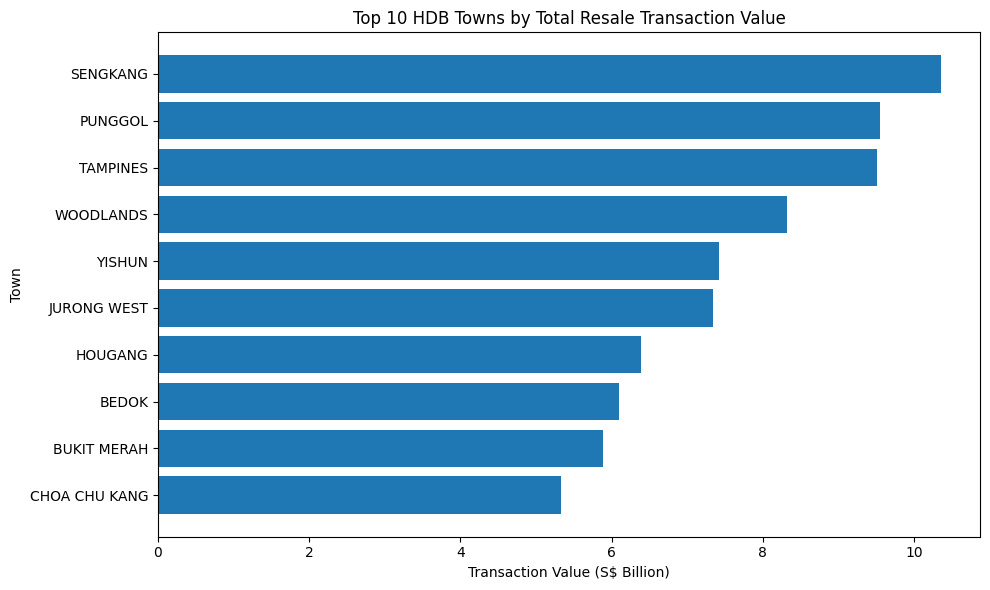

In [15]:
top10_value = town_value.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_value["town"],
    top10_value["transaction_value_billion"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 HDB Towns by Total Resale Transaction Value")
plt.xlabel("Transaction Value (S$ Billion)")
plt.ylabel("Town")

plt.tight_layout()
plt.show()

## Question 3 — Which towns are most expensive?

In [17]:
town_price_psm = (
    df.groupby("town")["price_per_sqm"]
    .median()
    .reset_index(name="median_price_per_sqm")
    .sort_values("median_price_per_sqm", ascending=False)
)

town_price_psm.head(10)

,town,median_price_per_sqm
7,CENTRAL AREA,7686.750
18,QUEENSTOWN,7528.740
4,BUKIT MERAH,6978.020
6,BUKIT TIMAH,6786.890
2,BISHAN,6416.000
15,MARINE PARADE,6338.460
14,KALLANG/WHAMPOA,6271.190
23,TOA PAYOH,5790.255
9,CLEMENTI,5785.120
17,PUNGGOL,5731.180


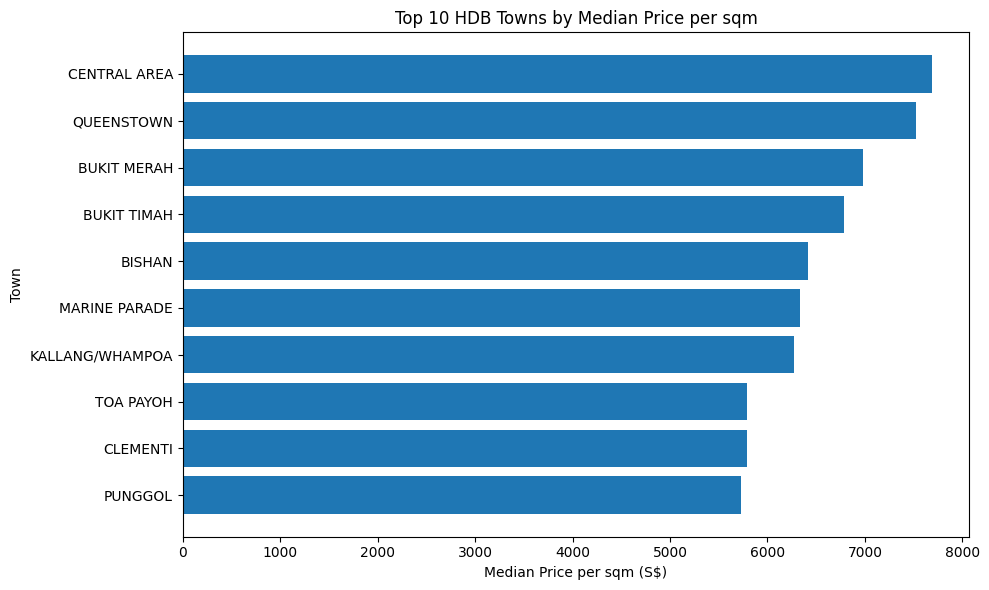

In [18]:
top10_price = town_price_psm.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_price["town"],
    top10_price["median_price_per_sqm"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 HDB Towns by Median Price per sqm")
plt.xlabel("Median Price per sqm (S$)")
plt.ylabel("Town")

plt.tight_layout()
plt.show()

## Question 4 — Which towns growing fastest?

In [25]:
growth_2025 = growth_analysis[
    growth_analysis["year"] == 2025
].copy()

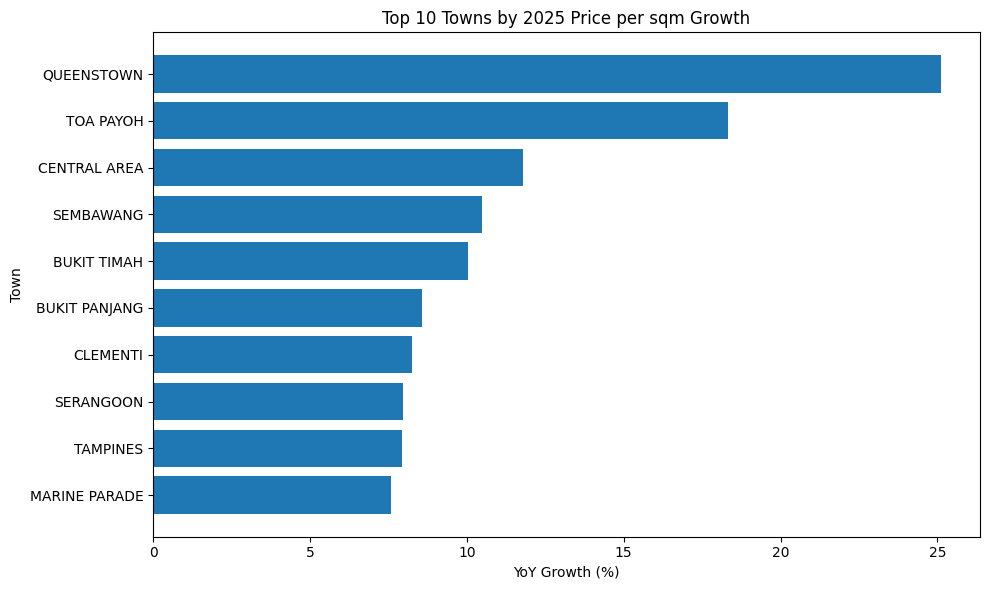

In [26]:
top_price_growth = (
    growth_2025
    .sort_values("price_growth_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_price_growth["town"],
    top_price_growth["price_growth_pct"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Towns by 2025 Price per sqm Growth")
plt.xlabel("YoY Growth (%)")
plt.ylabel("Town")

plt.tight_layout()
plt.show()